<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-36-lasso-regression-regularization?scriptVersionId=343919409" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [2]:
# Key: many features (5000), but only 50 are actually informative
# Linear regression gets confused by the 4950 noise features
# Lasso zeros them out and wins
X, y = make_regression(
    n_samples=1000,
    n_features=5000,       # lots of features
    n_informative=50,     # only 50 actually matter
    n_targets=1,
    noise=20,
    random_state=13
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [4]:
print(lr.coef_)
print(lr.intercept_)

[ 0.55990715  0.03870992 -2.77879336 ...  0.74789511  1.13650787
 -2.23131247]
1.1959029186847334


In [5]:
print(f"Linear R²: {r2_score(y_test, lr.predict(X_test)):.3f}")   # ~low

Linear R²: 0.183


In [6]:
for i in [0.1, 0.5, 1, 5, 10, 15, 30]:
    lasso = Lasso(alpha=i)
    lasso.fit(X_train, y_train)
    print(f"Lasso  R² (alpha={i}): {r2_score(y_test, lasso.predict(X_test)):.3f}")

Lasso  R² (alpha=0.1): 0.996
Lasso  R² (alpha=0.5): 0.996
Lasso  R² (alpha=1): 0.997
Lasso  R² (alpha=5): 0.990
Lasso  R² (alpha=10): 0.971
Lasso  R² (alpha=15): 0.940
Lasso  R² (alpha=30): 0.795


We come to know that r2_score is max when `alpha=0.1`

In [7]:
lasso = Lasso(alpha=1.0).fit(X_train, y_train)

print(f"Lasso  R²: {r2_score(y_test, lasso.predict(X_test)):.3f}") # ~high

Lasso  R²: 0.997


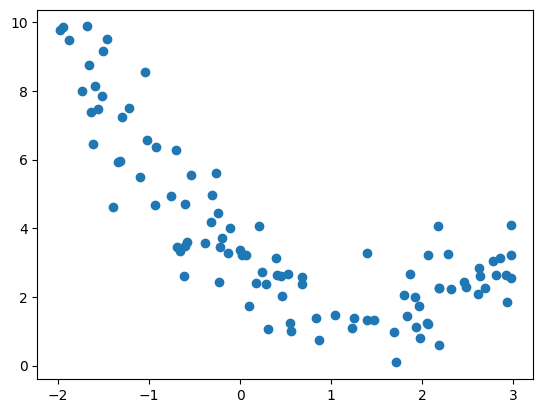

In [8]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

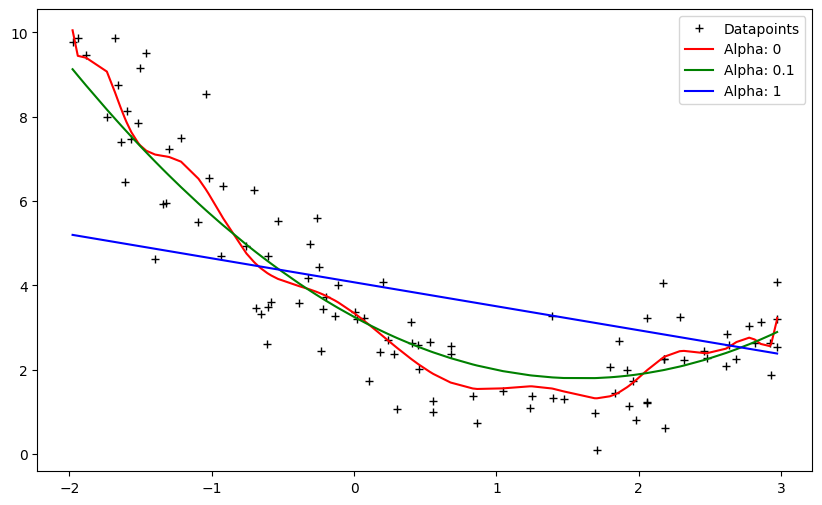

In [9]:
def get_preds_lasso(x1, x2, alpha):
    # If alpha is 0, use LinearRegression instead of Lasso
    if alpha == 0:
        model = Pipeline([
            ('poly_feats', PolynomialFeatures(degree=16)),
            ('scaler', StandardScaler()),
            ('linear', LinearRegression())
        ])
    else:
        model = Pipeline([
            ('poly_feats', PolynomialFeatures(degree=16)),
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=10000))
        ])
        
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'k+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Sort points for a smooth curve
    sort_idx = np.argsort(x1[:, 0])
    plt.plot(x1[sort_idx, 0], preds[sort_idx], color=c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [10]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

df = pd.DataFrame(data.data, columns = data.feature_names)
df['TARGET'] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(data.data ,data.target, test_size=0.2, random_state=42)

## 1. How are coefficients affected?

In [12]:
coefs = []
r2_scores = []

for i in [0.0000001, 0.1, 1, 10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train, y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

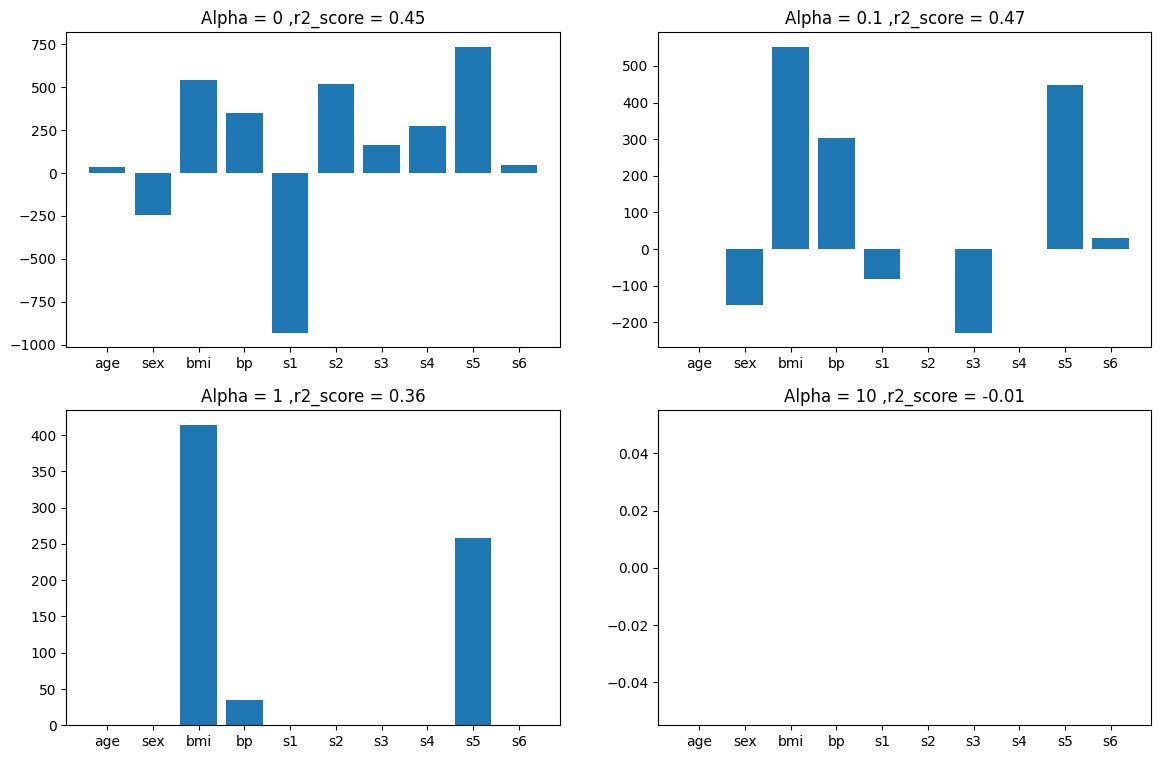

In [13]:
plt.figure(figsize=(14, 9))
plt.subplot(221)

plt.bar(data.feature_names, coefs[0])
plt.title(f'Alpha = 0 ,r2_score = {round(r2_scores[0], 2)}')

plt.subplot(222)
plt.bar(data.feature_names, coefs[1])
plt.title(f'Alpha = 0.1 ,r2_score = {round(r2_scores[1], 2)}')

plt.subplot(223)
plt.bar(data.feature_names, coefs[2])
plt.title(f'Alpha = 1 ,r2_score = {round(r2_scores[2], 2)}')

plt.subplot(224)
plt.bar(data.feature_names, coefs[3])
plt.title(f'Alpha = 10 ,r2_score = {round(r2_scores[3], 2)}')

plt.show()

## 2. Higher Coefficients are affected more

In [14]:
alphas = [0.0001, 0.001, 0.01, 0.1 ,1, 10, 100, 1000, 10000]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train, y_train)
    
    coefs.append(reg.coef_.tolist())

In [15]:
input_array = np.array(coefs)

coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0001,37.891667,-241.878244,542.524544,347.624893,-924.832045,513.033268,160.224210,274.036385,733.762619,48.690013
0.0010,37.780431,-241.103200,543.386372,346.914418,-864.934721,467.782935,131.468467,262.504646,711.841733,48.864159
0.0100,35.347451,-231.906664,551.303242,341.313469,-483.567140,165.990532,-25.834899,216.875803,566.815003,49.702475
0.1000,0.000000,-152.664779,552.697775,303.365158,-81.365007,-0.000000,-229.255776,0.000000,447.919525,29.642617
1.0000,0.000000,-0.000000,413.431848,34.830515,0.000000,0.000000,-0.000000,0.000000,258.152894,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
10000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


In [16]:
alphas = [0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train, y_train)
    
    coefs.append(reg.coef_.tolist())

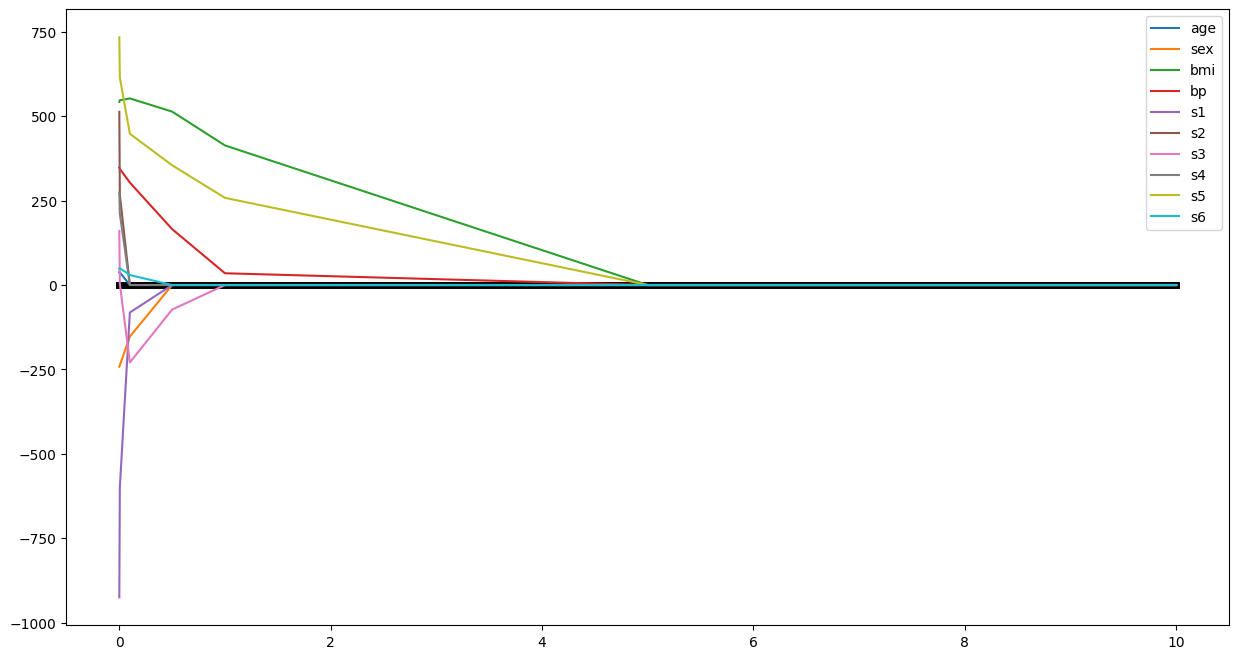

In [17]:
input_array = np.array(coefs).T

plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

## 3. Impact on Bias and Variance

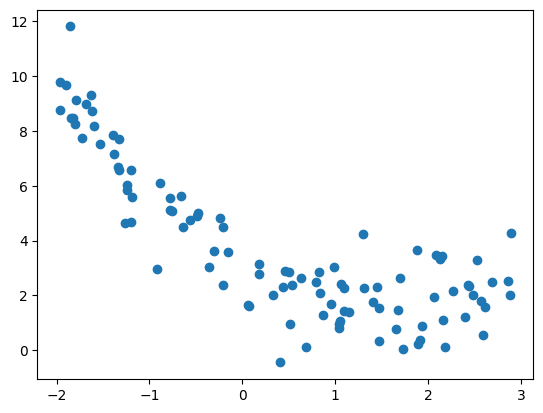

In [18]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X.reshape(100,1), y.reshape(100), test_size=0.2, random_state=2)

poly = PolynomialFeatures(degree=10)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [25]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0.01, 30, 50)  

X_tr = np.asarray(X_train)
y_tr = np.asarray(y_train)
X_te = np.asarray(X_test)
y_te = np.asarray(y_test)

loss, bias, variance = [], [], []

for i in alphas:
    # Scale features inside a Pipeline to guarantee convergence in every bootstrap round
    reg = make_pipeline(
        StandardScaler(),
        Lasso(alpha=i, max_iter=10000, tol=1e-3)
    )
    
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_tr, y_tr, X_te, y_te, 
        loss='mse',
        num_rounds=50,
        random_seed=123
    )
    
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

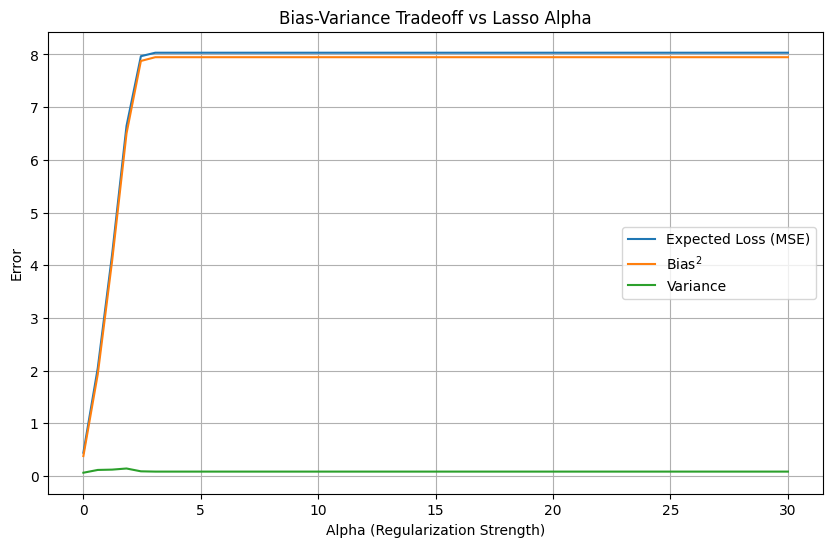

In [26]:
# Plotting the trade-off curve
plt.figure(figsize=(10, 6))
plt.plot(alphas, loss, label='Expected Loss (MSE)')
plt.plot(alphas, bias, label='Bias$^2$')
plt.plot(alphas, variance, label='Variance')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff vs Lasso Alpha')
plt.legend()
plt.grid(True)
plt.show()

## 4. Effect of Regularization on Loss Function

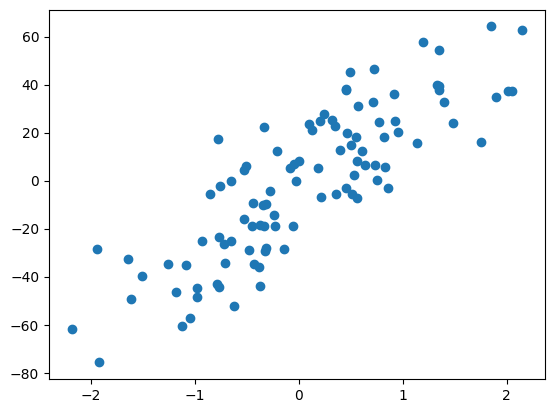

In [27]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

In [28]:
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


In [29]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*abs(m)

In [30]:
def predict(m):
    return m*X - 2.29

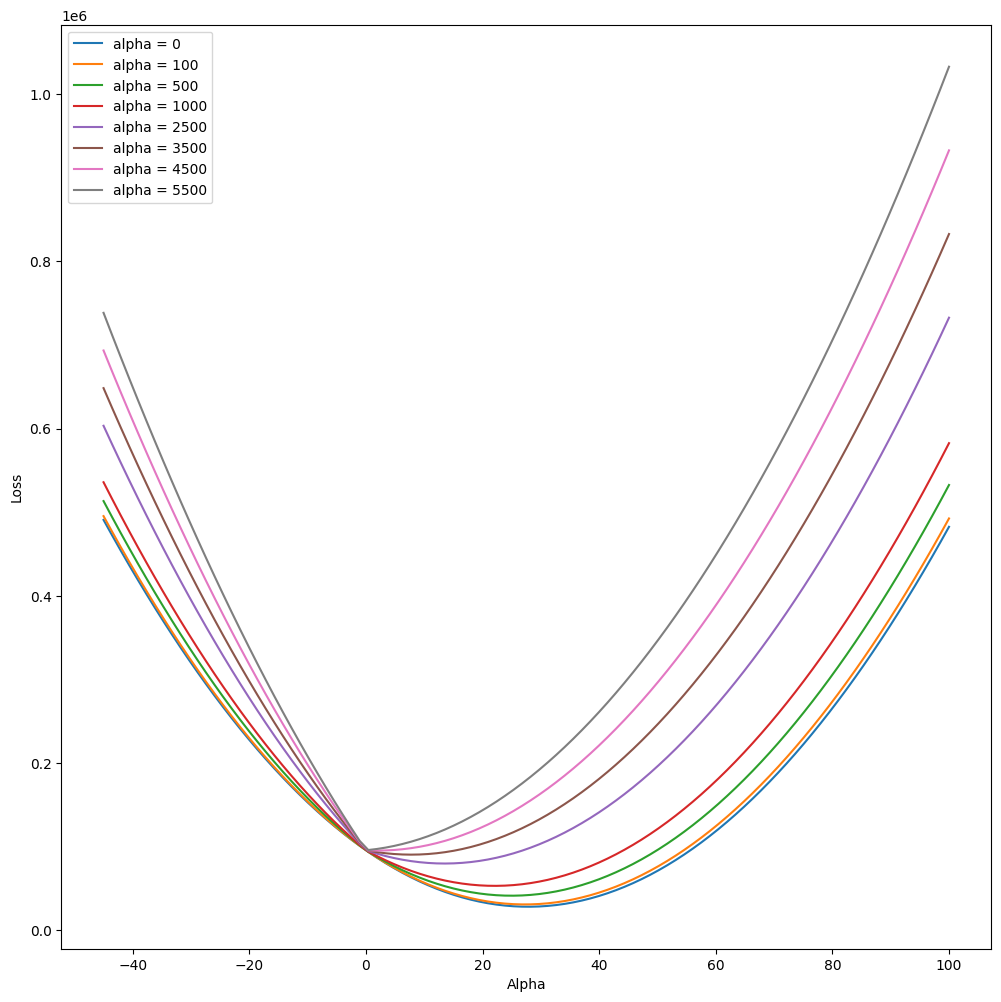

In [33]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(12,12))

for j in [0,100,500,1000,2500,3500,4500,5500]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))

plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()